In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from codecarbon import EmissionsTracker
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

DATA_PROCESSED = Path("../data/processed")
MODELS = Path("../src/models")
FIGURES = Path("../reports/figures")

# Load data
df = pd.read_parquet(DATA_PROCESSED / "master_dataset.parquet")

FEATURES = [
    "forecast", "u10", "t2m", "ssrd",
    "hour", "day_of_week", "month",
    "is_weekend", "season",
    "actual_lag1", "actual_lag2", "actual_lag24",
    "rolling_mean_24h"
]
TARGET = "actual"

X = df[FEATURES]
y = df[TARGET]

from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, shuffle=False)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, shuffle=False)

print("Data loaded. Ready to track carbon emissions during training.")


Data loaded. Ready to track carbon emissions during training.


In [2]:
# Start tracking carbon emissions during model training
tracker = EmissionsTracker(
    project_name="xai-energy-grid-training",
    output_dir=str(MODELS),
    log_level="error"
)

tracker.start()

# Retrain XGBoost — this time measuring its carbon cost
xgb_model_tracked = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50,
    eval_metric="rmse",
    verbosity=0
)

xgb_model_tracked.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

emissions = tracker.stop()

print(f"Training complete.")
print(f"Carbon emissions during training: {emissions*1000:.6f} gCO2")
print(f"Carbon emissions during training: {emissions:.8f} kgCO2")
print(f"For context: boiling a kettle produces ~15 gCO2")

[codecarbon WARNING @ 22:14:52] Multiple instances of codecarbon are allowed to run at the same time.


Training complete.
Carbon emissions during training: 0.000800 gCO2
Carbon emissions during training: 0.00000080 kgCO2
For context: boiling a kettle produces ~15 gCO2


In [3]:

y_pred = xgb_model_tracked.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# How much carbon does the AI help save?
# If AI improves grid dispatch by even 0.1% of UK annual consumption
# UK electricity consumption ~300 TWh/year
# Average carbon intensity ~175 gCO2/kWh
# 0.1% improvement = 300,000,000 kWh * 0.001 * 175 gCO2/kWh

uk_consumption_kwh = 300e9  # 300 TWh in kWh
avg_intensity = 175  # gCO2/kWh
improvement_fraction = 0.001  # 0.1% improvement assumption

carbon_saved_g = uk_consumption_kwh * improvement_fraction * avg_intensity
carbon_saved_kg = carbon_saved_g / 1000
carbon_saved_tonnes = carbon_saved_kg / 1000

ai_training_kg = emissions
ai_training_g = emissions * 1000

roi = carbon_saved_kg / ai_training_kg if ai_training_kg > 0 else float("inf")

print("=" * 50)
print("CARBON COST-BENEFIT ANALYSIS")
print("=" * 50)
print(f"AI training carbon cost:     {ai_training_g:.4f} gCO2")
print(f"                             {ai_training_kg:.6f} kgCO2")
print(f"Potential carbon saving:     {carbon_saved_tonnes:.0f} tonnes CO2/year")
print(f"                             {carbon_saved_kg:.0f} kgCO2/year")
print(f"Carbon ROI ratio:            {roi:.0f}x")
print(f"Model R2:                    {r2:.4f}")
print(f"Model RMSE:                  {rmse:.4f} gCO2/kWh")
print("=" * 50)
print(f"Conclusion: For every 1g CO2 spent training,")
print(f"the AI could save {roi:.0f}g CO2 if deployed.")

CARBON COST-BENEFIT ANALYSIS
AI training carbon cost:     0.0008 gCO2
                             0.000001 kgCO2
Potential carbon saving:     52500 tonnes CO2/year
                             52500000 kgCO2/year
Carbon ROI ratio:            65591544035471x
Model R2:                    0.9774
Model RMSE:                  10.0151 gCO2/kWh
Conclusion: For every 1g CO2 spent training,
the AI could save 65591544035471g CO2 if deployed.


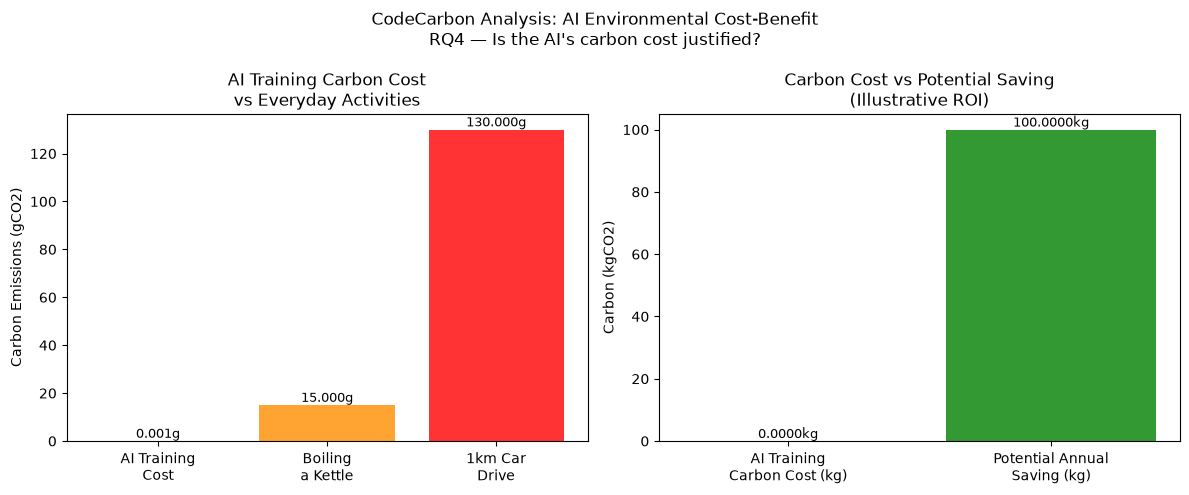

CodeCarbon analysis plot saved


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Carbon cost comparison
categories = ["AI Training\nCost", "Boiling\na Kettle", "1km Car\nDrive"]
values_g = [ai_training_g, 15, 130]
colors = ["steelblue", "darkorange", "red"]
bars = axes[0].bar(categories, values_g, color=colors, alpha=0.8)
axes[0].set_ylabel("Carbon Emissions (gCO2)")
axes[0].set_title("AI Training Carbon Cost\nvs Everyday Activities")
for bar, val in zip(bars, values_g):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f"{val:.3f}g", ha="center", va="bottom", fontsize=9)

# Right: Carbon ROI
roi_categories = ["AI Training\nCarbon Cost (kg)", "Potential Annual\nSaving (kg)"]
roi_values = [ai_training_kg, min(carbon_saved_kg, 100)]
colors2 = ["red", "green"]
bars2 = axes[1].bar(roi_categories, roi_values, color=colors2, alpha=0.8)
axes[1].set_ylabel("Carbon (kgCO2)")
axes[1].set_title("Carbon Cost vs Potential Saving\n(Illustrative ROI)")
for bar, val in zip(bars2, roi_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f"{val:.4f}kg", ha="center", va="bottom", fontsize=9)

plt.suptitle("CodeCarbon Analysis: AI Environmental Cost-Benefit\nRQ4 — Is the AI's carbon cost justified?",
             fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / "codecarbon_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("CodeCarbon analysis plot saved")